# Demonstration Data Visualization

Load an HDF5 demo file from `data/` and plot joint positions over time to
verify demonstration quality before training an imitation-learning policy.

In [7]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

## 1. Load a demo file

Point `DEMO_PATH` to any `.h5` file saved by `scripts/collect_data.py`.

In [8]:
DATA_DIR = Path("..") / "data"

# List available demos
demos = sorted(DATA_DIR.glob("*.h5"))
print(f"Found {len(demos)} demo(s):")
for d in demos:
    print(f"  {d.name}")

# Select the most recent demo (or set manually)
DEMO_PATH = demos[-1] if demos else None
print(f"\nUsing: {DEMO_PATH}")

Found 1 demo(s):
  demo_20260305_180146.h5

Using: ../data/demo_20260305_180146.h5


In [9]:
# Load HDF5 data
with h5py.File(str(DEMO_PATH), "r") as f:
    qpos = f["observations/qpos"][:]
    qvel = f["observations/qvel"][:]
    ctrl = f["actions/ctrl"][:]
    n_steps = f["metadata"].attrs["n_steps"]
    created = f["metadata"].attrs["created_at"]

print(f"Demo created: {created}")
print(f"Steps: {n_steps}")
print(f"qpos shape: {qpos.shape}")
print(f"qvel shape: {qvel.shape}")
print(f"ctrl shape: {ctrl.shape}")

Demo created: 2026-03-05T18:01:46.086100
Steps: 101
qpos shape: (101, 30)
qvel shape: (101, 28)
ctrl shape: (101, 16)


In [ ]:
# The free joint occupies qpos[0:7] (3 pos + 4 quat) and qvel[0:6]
# Finger joints start right after: qpos[7:23], qvel[6:22]
FINGER_Q_START = 7
FINGER_V_START = 6
N_FINGERS = 16

qpos_fingers = qpos[:, FINGER_Q_START : FINGER_Q_START + N_FINGERS]
qvel_fingers = qvel[:, FINGER_V_START : FINGER_V_START + N_FINGERS]
# ctrl already maps 1-to-1 to the 16 finger actuators
timesteps = np.arange(qpos.shape[0])

print(f"Finger qpos: {qpos_fingers.shape}  |  finger qvel: {qvel_fingers.shape}  |  ctrl: {ctrl.shape}")

## 2. Joint positions over time

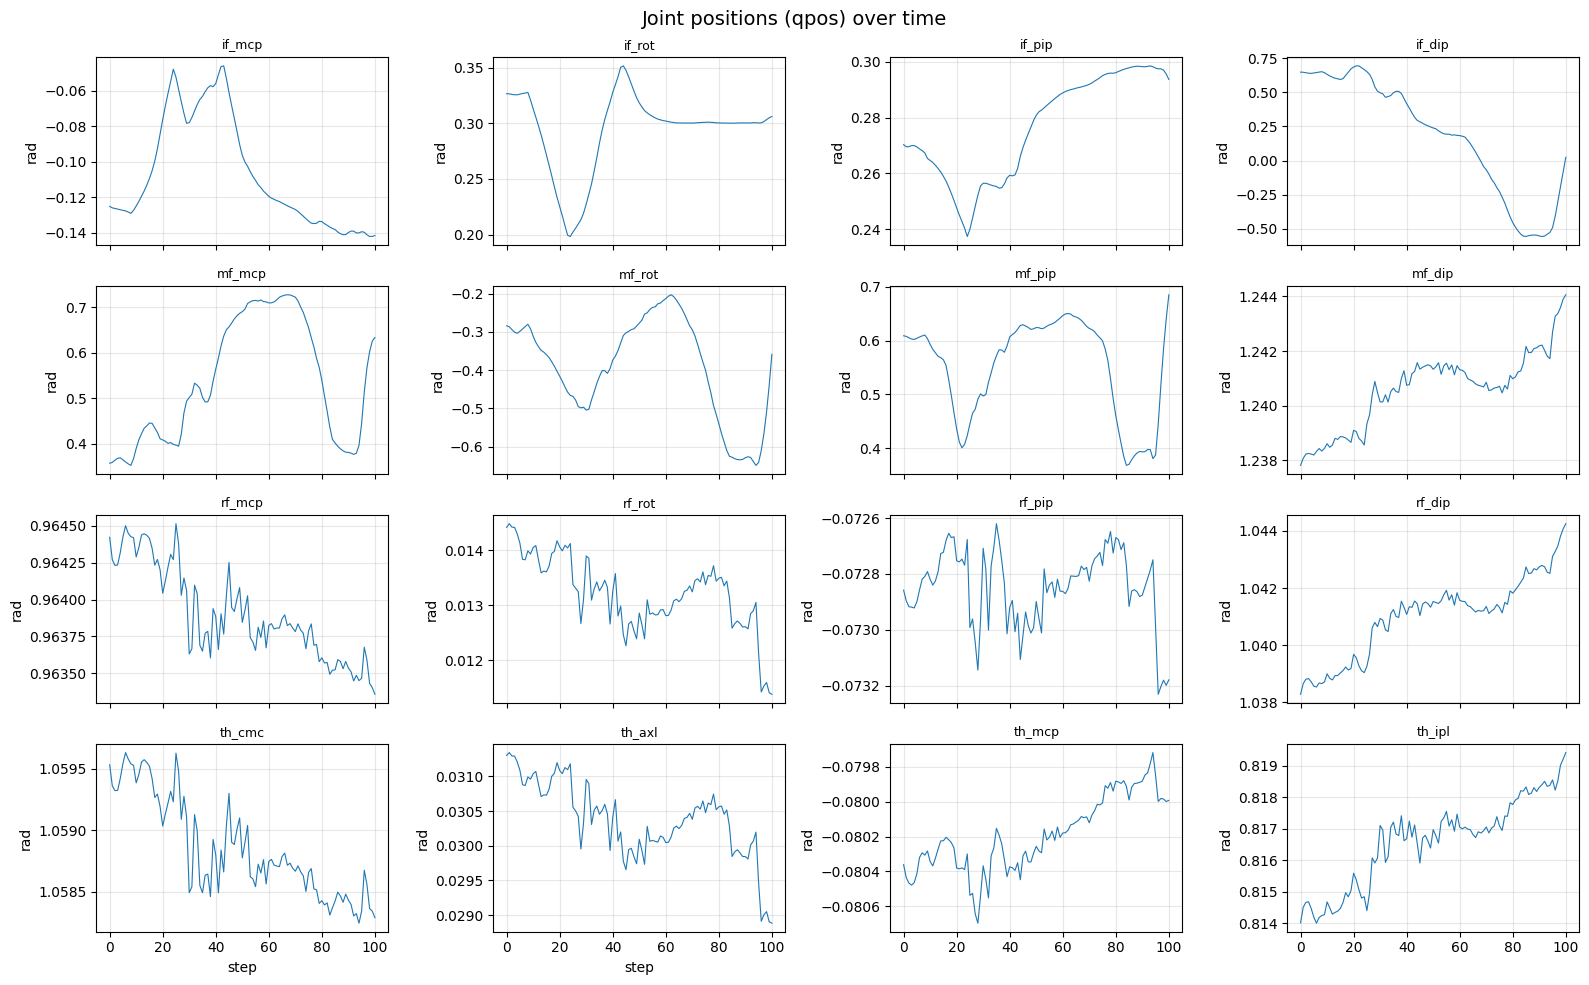

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True)
fig.suptitle("Joint positions (qpos) over time", fontsize=14)

joint_names = [
    "if_mcp", "if_rot", "if_pip", "if_dip",
    "mf_mcp", "mf_rot", "mf_pip", "mf_dip",
    "rf_mcp", "rf_rot", "rf_pip", "rf_dip",
    "th_cmc", "th_axl", "th_mcp", "th_ipl",
]

for i, ax in enumerate(axes.flat):
    ax.plot(timesteps, qpos_fingers[:, i], linewidth=0.8)
    ax.set_title(joint_names[i], fontsize=9)
    ax.set_ylabel("rad")
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("step")
axes[-1, 1].set_xlabel("step")
plt.tight_layout()
plt.show()

## 3. Control signals (actions) over time

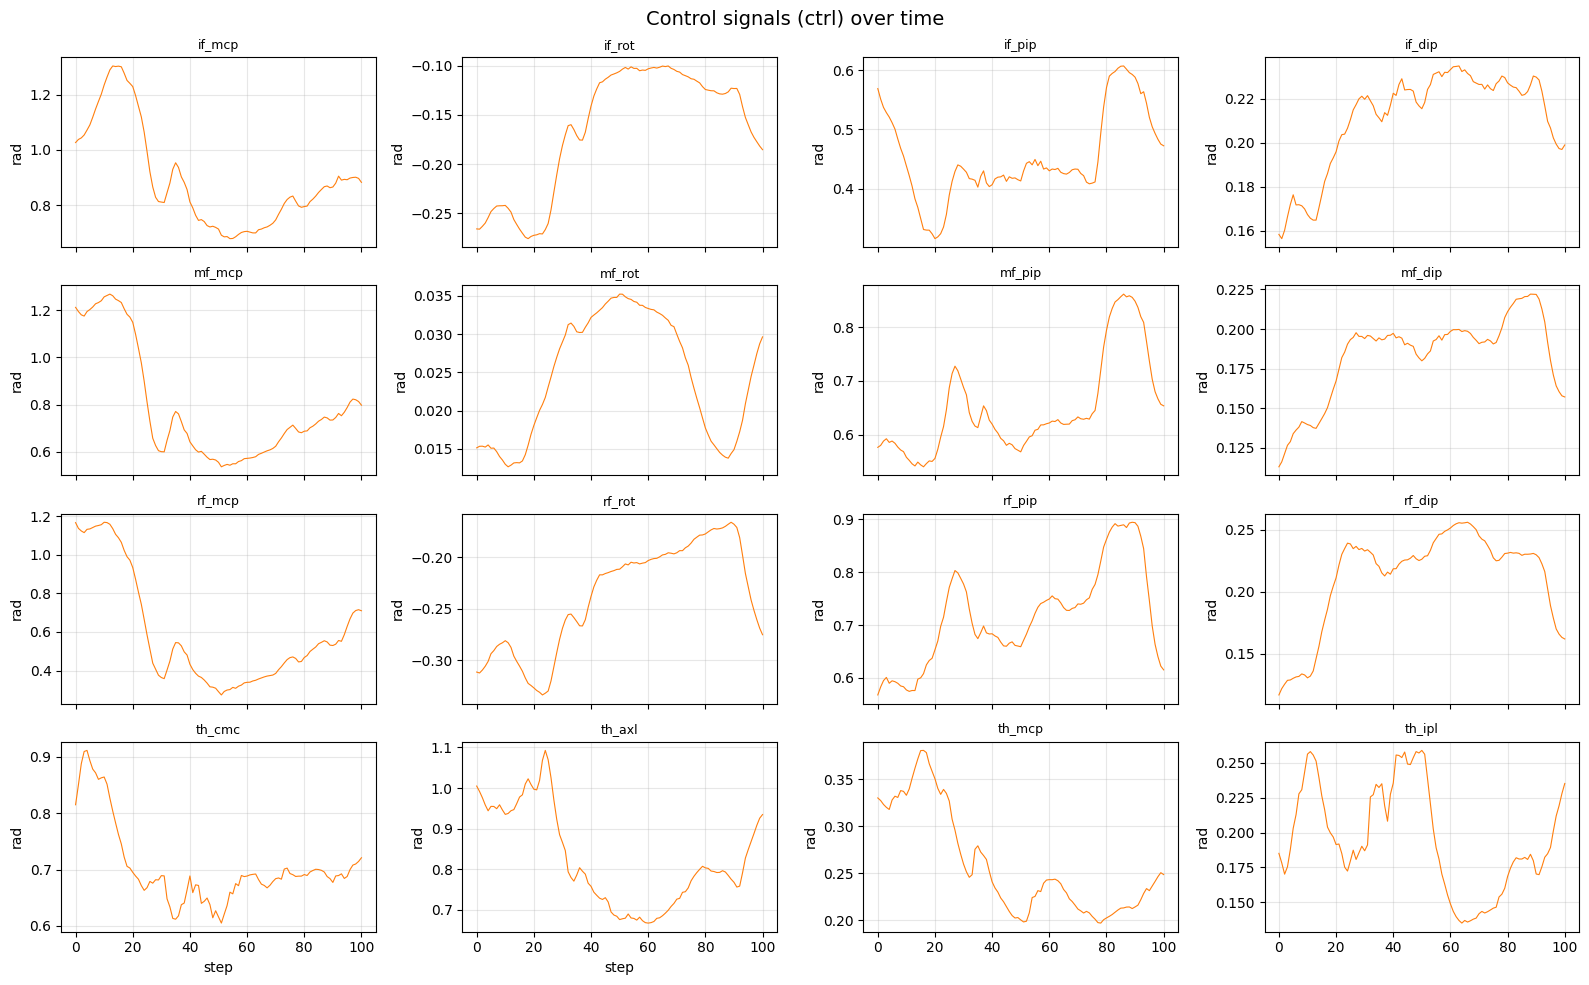

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True)
fig.suptitle("Control signals (ctrl) over time", fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.plot(timesteps, ctrl[:, i], linewidth=0.8, color="tab:orange")
    ax.set_title(joint_names[i], fontsize=9)
    ax.set_ylabel("rad")
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("step")
axes[-1, 1].set_xlabel("step")
plt.tight_layout()
plt.show()

## 4. Joint velocities (sanity check)

Large velocity spikes indicate tracking glitches — filter parameters may
need tuning if this happens frequently.

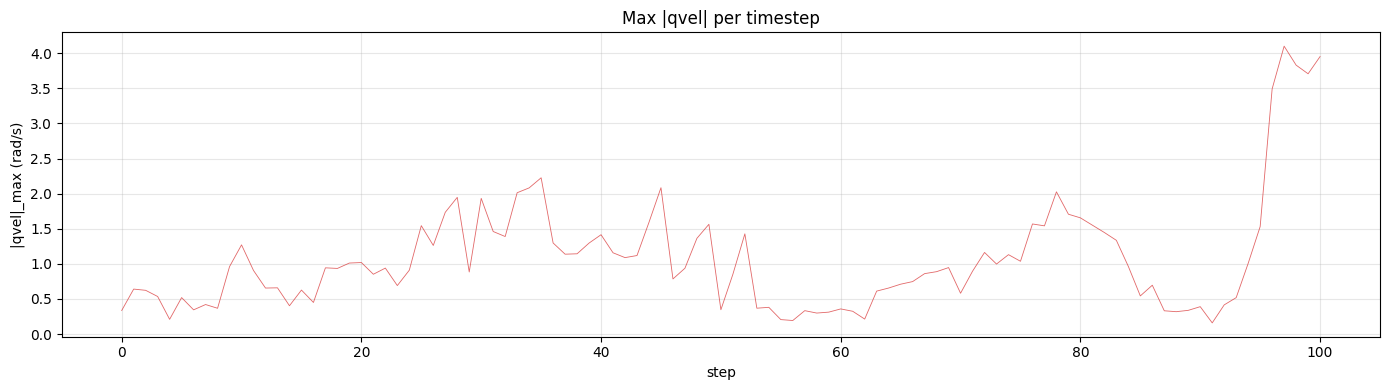

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_title("Max |qvel| per timestep  (finger joints only)")
ax.plot(timesteps, np.max(np.abs(qvel_fingers), axis=1), linewidth=0.6,
        color="tab:red", alpha=0.7)
ax.set_xlabel("step")
ax.set_ylabel("|qvel|_max (rad/s)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Demo statistics summary

In [ ]:
import pandas as pd

stats = []
for i, name in enumerate(joint_names):
    q = qpos_fingers[:, i]
    c = ctrl[:, i]
    stats.append({
        "joint":            name,
        "qpos_mean":        round(float(np.mean(q)), 4),
        "qpos_std":         round(float(np.std(q)), 4),
        "qpos_min":         round(float(np.min(q)), 4),
        "qpos_max":         round(float(np.max(q)), 4),
        "ctrl_mean":        round(float(np.mean(c)), 4),
        "tracking_err_mean":round(float(np.mean(np.abs(q - c))), 4),
    })

df = pd.DataFrame(stats)
print(f"Demo: {DEMO_PATH.name}  |  {n_steps} steps  |  created: {created}\n")
pd.set_option("display.float_format", "{:.4f}".format)
df

## 6. Tracking error: qpos vs ctrl (position actuator lag)

A high residual between `qpos` (actual angle) and `ctrl` (target) means the
actuators are saturated or the gains are too low.

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True)
fig.suptitle("Tracking error  |qpos - ctrl|  per joint", fontsize=14)

for i, ax in enumerate(axes.flat):
    err = np.abs(qpos_fingers[:, i] - ctrl[:, i])
    ax.fill_between(timesteps, err, alpha=0.6, color="tab:purple")
    ax.axhline(np.mean(err), color="black", linewidth=0.8, linestyle="--",
               label=f"mean={np.mean(err):.3f}")
    ax.set_title(joint_names[i], fontsize=9)
    ax.set_ylabel("rad")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("step")
axes[-1, 1].set_xlabel("step")
plt.tight_layout()
plt.show()

## 7. Per-finger group overview

MCP (curl base), PIP/DIP (curl tip), and rotation joints grouped by finger.

In [ ]:
finger_groups = {
    "Index":  {"mcp": 0, "rot": 1, "pip": 2,  "dip": 3},
    "Middle": {"mcp": 4, "rot": 5, "pip": 6,  "dip": 7},
    "Ring":   {"mcp": 8, "rot": 9, "pip": 10, "dip": 11},
    "Thumb":  {"cmc": 12, "axl": 13, "mcp": 14, "ipl": 15},
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
fig.suptitle("Per-finger qpos (solid) vs ctrl (dashed)", fontsize=13)

colors = {"mcp": "tab:blue", "pip": "tab:green", "dip": "tab:orange",
          "rot": "tab:gray",  "cmc": "tab:blue",  "axl": "tab:green",
          "ipl": "tab:orange"}

for ax, (finger, joints) in zip(axes, finger_groups.items()):
    for jname, idx in joints.items():
        c = colors.get(jname, "tab:purple")
        ax.plot(timesteps, qpos_fingers[:, idx], linewidth=0.9, color=c, label=jname)
        ax.plot(timesteps, ctrl[:, idx], linewidth=0.9, color=c,
                linestyle="--", alpha=0.5)
    ax.set_title(finger, fontsize=11)
    ax.set_xlabel("step")
    ax.set_ylabel("rad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Smoothness analysis (jerk)

Jerk = second derivative of position. High jerk = jerky, hard-to-imitate motions.
Flat lines = smooth, robot-friendly demonstrations.

In [ ]:
jerk = np.diff(np.diff(qpos_fingers, axis=0), axis=0)   # (N-2, 16)
rms_jerk = np.sqrt(np.mean(jerk**2, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(joint_names, rms_jerk, color="tab:teal", alpha=0.8)
axes[0].set_title("RMS Jerk per joint  (lower = smoother)")
axes[0].set_ylabel("rad/step²")
axes[0].set_xticklabels(joint_names, rotation=45, ha="right", fontsize=8)
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].plot(np.arange(len(jerk)), np.max(np.abs(jerk), axis=1),
             linewidth=0.7, color="tab:red", alpha=0.8)
axes[1].set_title("Max |jerk| over time  (spikes = glitches)")
axes[1].set_xlabel("step")
axes[1].set_ylabel("rad/step²")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSmoothest joint:  {joint_names[int(np.argmin(rms_jerk))]}  (RMS jerk={np.min(rms_jerk):.4f})")
print(f"Jerkiest joint:   {joint_names[int(np.argmax(rms_jerk))]}  (RMS jerk={np.max(rms_jerk):.4f})")

## 9. Demo quality verdict

In [ ]:
JERK_THRESH      = 0.05   # rad/step²
TRACKING_THRESH  = 0.10   # rad
QVEL_THRESH      = 5.0    # rad/s

mean_tracking = float(np.mean(np.abs(qpos_fingers - ctrl)))
peak_qvel     = float(np.max(np.abs(qvel_fingers)))
mean_jerk     = float(np.mean(rms_jerk))

print("=" * 55)
print(f"  Demo quality report — {DEMO_PATH.name}")
print("=" * 55)
print(f"  Duration:          {n_steps} steps  (~{n_steps/30:.1f}s at 30 Hz)")
print(f"  Mean tracking err: {mean_tracking:.4f} rad  ", end="")
print("✅" if mean_tracking < TRACKING_THRESH else "⚠️  high — check actuator gains")
print(f"  Mean RMS jerk:     {mean_jerk:.4f} rad/step²  ", end="")
print("✅" if mean_jerk < JERK_THRESH else "⚠️  jerky — slow down or raise filter beta")
print(f"  Peak |qvel|:       {peak_qvel:.4f} rad/s  ", end="")
print("✅" if peak_qvel < QVEL_THRESH else "⚠️  velocity spikes detected")

overall = all([mean_tracking < TRACKING_THRESH,
               mean_jerk < JERK_THRESH,
               peak_qvel < QVEL_THRESH])
print()
print("  → Overall:", "GOOD — ready for training 🎯" if overall else "NEEDS IMPROVEMENT — see warnings above")